The idea for this notebook is to obtain plots that show low variance between coherent and incoherent text, trying to prove that my theory works.

What can we plot:

- Number of tokens per generation 

- Embedding vector entropy:
    - Spread of representations: how “diverse” or “informationally rich” the embeddings are overall.

    - By shuffling, we don’t change the per-token embedding distribution since the individual tokens remain the same.

    - Therefore, global entropy (across embeddings or across dimensions) should remain similar between original and shuffled sets.

- Average cossine similarity between sentences:
    - Compute the pairwise cosine similarity between average token embeddings (or between sentence embeddings) for each condition.
    - Compare similarity matrices of original vs. shuffled text.

## Imports w/ Right side padding

In [1]:
import torch
import json
from transformers import AutoTokenizer, AutoModelForCausalLM
import matplotlib.pyplot as plt
import random 
import re
rng = random.Random(42)

/home/jdias/miniconda3/envs/vf/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
#model loading functions

def choose_device(device):
    if device==0:
        return 'cuda:0'
    elif device==1:
        return 'cuda:1'
    elif device ==-1:
        return 'cpu'
    else:
        raise Exception('Return 0 or 1 for GPUs or -1 for CPU')

def load_device(cuda_id):
    cuda = choose_device(cuda_id)
    device = torch.device(cuda if torch.cuda.is_available() else "cpu")
    return device

def load_AutoModel(model_id,cuda_id):
    
    tokenizer = AutoTokenizer.from_pretrained(model_id, padding_side = "right") 
    tokenizer.pad_token_id = tokenizer.eos_token_id #required in llama because no padding token is defined
    model = AutoModelForCausalLM.from_pretrained(model_id, torch_dtype=torch.bfloat16)
    terminators = [
        tokenizer.eos_token_id,
        tokenizer.convert_tokens_to_ids("<|eot_id|>")
    ]
    device = load_device(cuda_id)
    model = model.to(device)

    return tokenizer, model, device, terminators


def load_prompts(prompt_type, prompt_topic):
    #load prompt from .txt
    if prompt_type == 'completion':
        with open('../prompts-comp/'+prompt_topic+'.txt') as file:
            prompt = file.read()
    elif prompt_type == 'generation':
        with open('../prompts-gen/'+prompt_topic+'.txt') as file:
            prompt = file.read()
        prompt = json.loads(prompt, strict=False)
    return prompt

def prepare_llama_prompt(tokenizer, prompt, device):
    text = tokenizer.apply_chat_template(prompt, add_generation_prompt=True, tokenize=False) 
    inputs = tokenizer(text, padding="longest", return_tensors="pt") #transform into pt tensors
    inputs = {key: val.to(device) for key, val in inputs.items()} #move inputs into cuda
    return inputs

def llama_gen(model, inputs, tokenizer, terminators, num_generations):
    generations = model.generate(
        **inputs,
        max_new_tokens=400,
        do_sample=True,
        temperature=0.7,
        top_p=0.9,
        pad_token_id=tokenizer.eos_token_id,
        eos_token_id=terminators,
        num_return_sequences=num_generations  
    )

    return generations

In [3]:
model_id = "meta-llama/Meta-Llama-3.1-8B-Instruct"
tokenizer, model, device, terminators = load_AutoModel(model_id, cuda_id=0)

Loading checkpoint shards: 100%|██████████| 4/4 [00:00<00:00, 135.28it/s]


## Plotting the number of tokens per generation

In [4]:
def split_sentences(text):
    """
    Fast splitter on . ! ?
    """
    text = text.strip()
    if not text:
        return []
    sents = re.split(r'(?<=[.!?])\s+', text)
    return [s for s in sents if s]

def shuffle_sentences(text, rng):
    sents = split_sentences(text)
    if len(sents) <= 1:
        return text
    
    shuffled = sents[:] #copy
    #rng.shuffle(shuffled)
    random.shuffle(shuffled)

    #ensure itss actually different 
    if shuffled == sents:
        shuffled = sents[1:] + sents[:1]
    return " ".join(shuffled) #join sentences again

def gen_ids_to_decoded(tokenizer, model_inputs, gen_ids):
    prompt_text = tokenizer.decode(model_inputs['input_ids'][0], skip_special_tokens=True)
    decoded_gens = tokenizer.batch_decode(gen_ids, skip_special_tokens=True)

    return [decoded_generation[len(prompt_text):] for decoded_generation in decoded_gens] #list of decoded stories

def shuffle_and_encode(rng, decoded_stories, gen_ids, tokenizer,tensor_size_prompt):
    
    shuffled_stories = [shuffle_sentences(s, rng) for s in decoded_stories]
    nr_gens = len(shuffled_stories)
    max_gen_size = int(getattr(gen_ids[:,tensor_size_prompt:], "shape", [nr_gens, 0])[1])  

    shuffled_encoded = tokenizer(
        shuffled_stories,
        add_special_tokens=False,         
        padding="max_length",
        truncation=True,
        max_length=max_gen_size,
        return_tensors="pt",
    )
    shuffled_input_ids = shuffled_encoded["input_ids"]
    shuffled_input_ids = shuffled_input_ids.to(device)   

    return shuffled_input_ids
    

def load_prompt_and_gen(prompt_type, prompt_topic, tokenizer, terminators, device):
    prompt = load_prompts(prompt_type, prompt_topic)
    model_inputs = prepare_llama_prompt(tokenizer, prompt, device)
    gen_ids = llama_gen(model, model_inputs, tokenizer, terminators, num_generations=100)

    return gen_ids, model_inputs


Load tensors - compute the number of tokens in tensor.
Also, decode them, shuffled them, tokenize them again and count it.

### prompt-based

In [5]:
viktor_tensors, viktor_inputs = load_prompt_and_gen(prompt_type = "generation", prompt_topic="viktor", tokenizer=tokenizer, terminators=terminators, device=device)
prague_tensors, prague_inputs = load_prompt_and_gen(prompt_type = "generation", prompt_topic="prague", tokenizer=tokenizer, terminators=terminators, device=device)
sciencefic_tensors, sciencefic_inputs = load_prompt_and_gen(prompt_type = "generation", prompt_topic="sciencefic", tokenizer=tokenizer, terminators=terminators, device=device)

In [6]:
viktor_prompt_size = viktor_inputs['input_ids'].shape[1]
prague_prompt_size = prague_inputs['input_ids'].shape[1]
sciencefic_prompt_size = sciencefic_inputs['input_ids'].shape[1]

In [7]:
decoded_viktor = gen_ids_to_decoded(tokenizer=tokenizer, model_inputs=viktor_inputs, gen_ids=viktor_tensors)
decoded_prague = gen_ids_to_decoded(tokenizer=tokenizer, model_inputs=prague_inputs, gen_ids=prague_tensors)
decoded_sciencefic = gen_ids_to_decoded(tokenizer=tokenizer, model_inputs=sciencefic_inputs, gen_ids=sciencefic_tensors)

In [8]:
shuffled_viktor_ids = shuffle_and_encode(rng=rng, decoded_stories=decoded_viktor, gen_ids=viktor_tensors, tokenizer=tokenizer, tensor_size_prompt=viktor_prompt_size)
shuffled_prague_ids = shuffle_and_encode(rng=rng, decoded_stories=decoded_prague, gen_ids=prague_tensors, tokenizer=tokenizer,tensor_size_prompt=prague_prompt_size)
shuffled_sciencefic_ids = shuffle_and_encode(rng=rng, decoded_stories=decoded_sciencefic, gen_ids=sciencefic_tensors, tokenizer=tokenizer, tensor_size_prompt=sciencefic_prompt_size)

In [29]:
viktor_prompt_size = viktor_inputs['input_ids'].shape[1]
prague_prompt_size = prague_inputs['input_ids'].shape[1]
sciencefic_prompt_size = sciencefic_inputs['input_ids'].shape[1]

In [ ]:
import pandas as pd

num_generations = shuffled_viktor_ids.shape[0]

all_records = []

for gen_idx in range(num_generations):
    gen_tokens = shuffled_viktor_ids[gen_idx]
    # convert to Python list
    token_ids = gen_tokens.tolist()
    # get token strings
    token_texts = tokenizer.convert_ids_to_tokens(token_ids)
    # decode each token individually (to see leading spaces, etc.)
    decoded_pieces = [tokenizer.decode([tid]) for tid in token_ids]
    
    for token_idx, (tid, tok, piece) in enumerate(zip(token_ids, token_texts, decoded_pieces)):
        all_records.append({
            "generation_index": gen_idx,
            "token_index": token_idx,
            "token_id": tid,
            "token_text": tok,
            "decoded_piece": piece,
        })

# create DataFrame
df_tokens = pd.DataFrame(all_records)

# show sample
print(df_tokens.head(20))


    generation_index  token_index  token_id token_text decoded_piece
0                  0            0        53          V             V
1                  0            1      1609         ik            ik
2                  0            2     11222        tor           tor
3                  0            3       596         's            's
4                  0            4     27117    Ġblonde        blonde
5                  0            5      7013      Ġhair          hair
6                  0            6       574       Ġwas           was
7                  0            7     36241      Ġmuss          muss
8                  0            8       291         ed            ed
9                  0            9        11          ,             ,
10                 0           10       719       Ġbut           but
11                 0           11       813       Ġhis           his
12                 0           12     15648     Ġsmile         smile
13                 0           13 

In [30]:
viktor_gen_only = viktor_tensors[:, viktor_prompt_size:]
prague_gen_only = prague_tensors[:, prague_prompt_size:]
sciencefic_gen_only = sciencefic_tensors[:, sciencefic_prompt_size:]

#### Having end of sentence padding - all will be the same

In [31]:
num_tokens_viktor = [t.shape[0] for t in viktor_gen_only]
num_tokens_prague = [t.shape[0] for t in prague_gen_only]
num_tokens_sciencefic = [t.shape[0] for t in sciencefic_gen_only]

num_tokens_viktor_shuffled = [t.shape[0] for t in shuffled_viktor_ids]
num_tokens_prague_shuffled = [t.shape[0] for t in shuffled_prague_ids]
num_tokens_sciencefic_shuffled = [t.shape[0] for t in shuffled_sciencefic_ids]

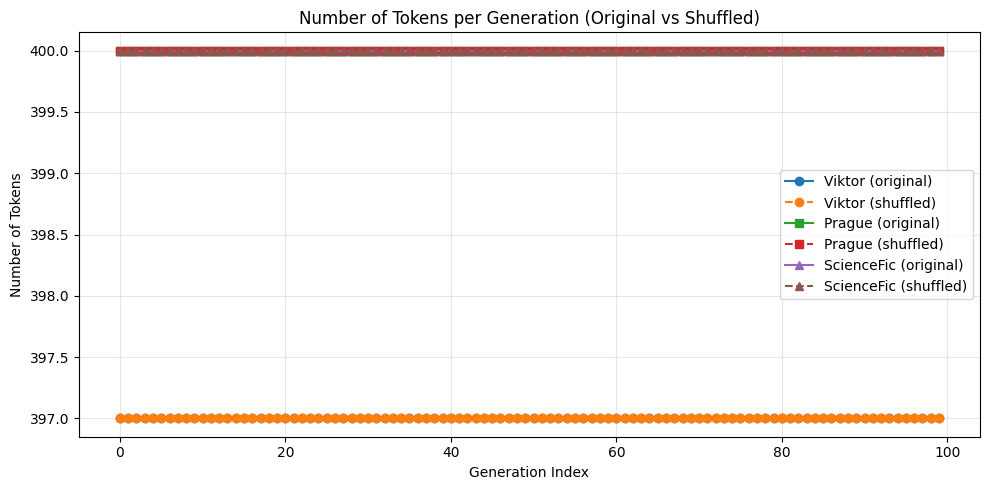

In [32]:
plt.figure(figsize=(10, 5))

plt.plot(num_tokens_viktor, label="Viktor (original)", marker='o', linestyle='-')
plt.plot(num_tokens_viktor_shuffled, label="Viktor (shuffled)", marker='o', linestyle='--')

plt.plot(num_tokens_prague, label="Prague (original)", marker='s', linestyle='-')
plt.plot(num_tokens_prague_shuffled, label="Prague (shuffled)", marker='s', linestyle='--')

plt.plot(num_tokens_sciencefic, label="ScienceFic (original)", marker='^', linestyle='-')
plt.plot(num_tokens_sciencefic_shuffled, label="ScienceFic (shuffled)", marker='^', linestyle='--')

plt.title("Number of Tokens per Generation (Original vs Shuffled)")
plt.xlabel("Generation Index")
plt.ylabel("Number of Tokens")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

#### Ignoring end of sentence padding